# IN5450 Project 3
## Theodor Wålberg
### Setup

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import scipy.signal

mat_data = scipy.io.loadmat("mimo_project.mat")

tdma_data = mat_data["tdma_data"]    # [Nt, Nrx, Ntx]
cdma_data = mat_data["cdma_data"]    # [Nt, Nrx]
rx_pos = mat_data["rx_pos"].flatten()
tx_pos = mat_data["tx_pos"].flatten()
fs = mat_data["fs"].item()

c = 340
B = 10000
fc = 10000
Tp = 0.01

Nt, Nrx, Ntx = tdma_data.shape
print(f"tdma_data shape: {tdma_data.shape}")
print(f"cdma_data shape: {cdma_data.shape}")
print(f"fs = {fs} Hz, Nrx = {Nrx}, Ntx = {Ntx}")


tdma_data shape: (10000, 32, 2)
cdma_data shape: (10000, 32)
fs = 200000 Hz, Nrx = 32, Ntx = 2


### Part 1: Pulse compression

tdma_compressed shape: (10000, 32, 2)


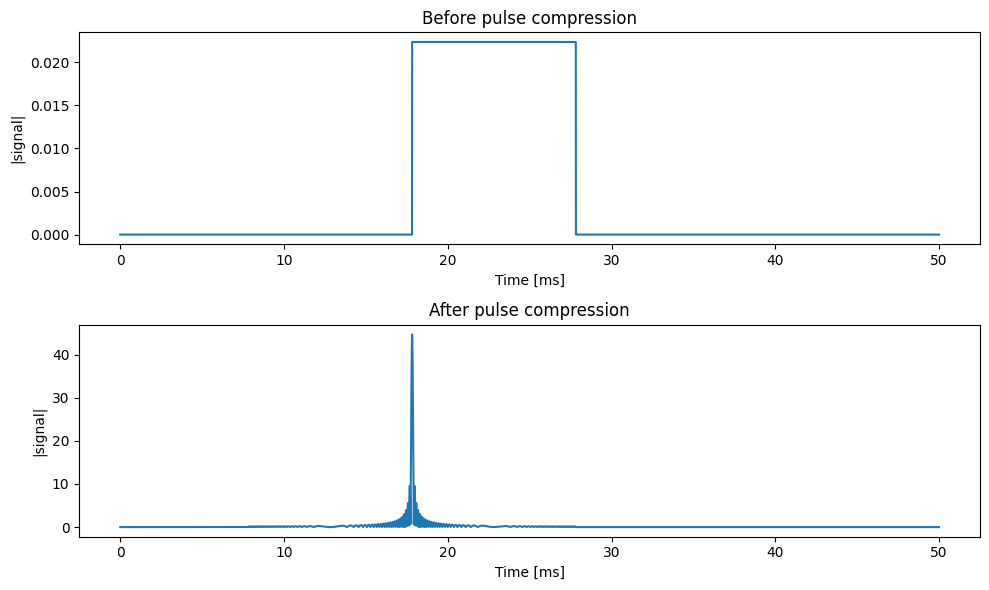

In [67]:
alpha = B / Tp
t_p = np.arange(0, Tp, 1 / fs)

s_tx_up = np.exp(1j * 2 * np.pi * ((fc - B / 2) * t_p + alpha * t_p**2 / 2))
s_tx_down = np.exp(1j * 2 * np.pi * ((fc + B / 2) * t_p - alpha * t_p**2 / 2))


def pulse_compression(data, replica):
    corr = scipy.signal.correlate(data, replica, mode="full")
    return corr[len(replica) - 1:]


tdma_compressed = np.stack(
    [
        np.stack(
            [pulse_compression(tdma_data[:, rx, tx], s_tx_up) for rx in range(Nrx)],
            axis=1,
        )
        for tx in range(Ntx)
    ],
    axis=2,
)
print(f"tdma_compressed shape: {tdma_compressed.shape}")

rx_idx = 0
tx_idx = 0
t_axis = np.arange(tdma_data.shape[0]) / fs

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(t_axis * 1e3, np.abs(tdma_data[:, rx_idx, tx_idx]))
axes[0].set_title("Before pulse compression")
axes[0].set_xlabel("Time [ms]")
axes[0].set_ylabel("|signal|")

t_axis_comp = np.arange(tdma_compressed.shape[0]) / fs
axes[1].plot(t_axis_comp * 1e3, np.abs(tdma_compressed[:, rx_idx, tx_idx]))
axes[1].set_title("After pulse compression")
axes[1].set_xlabel("Time [ms]")
axes[1].set_ylabel("|signal|")

plt.tight_layout()
plt.show()


The difference is quite obvious. The pulse compressed signal is much narrower than the original. This increases the time resolution, while allowing the signal to be wide with a lot of energy to travel far.

Investigate the pulse compressed timeseries, and estimate the practical time-resolution by calculating the Full Width Half Maximum (FWHM) on the magnitude squared signal on one timeseries. Compare with the theoretical.

Theoretical: δτ = 1/B = 100.00 µs
Measured FWHM: 88.60 µs
Ratio: 0.886


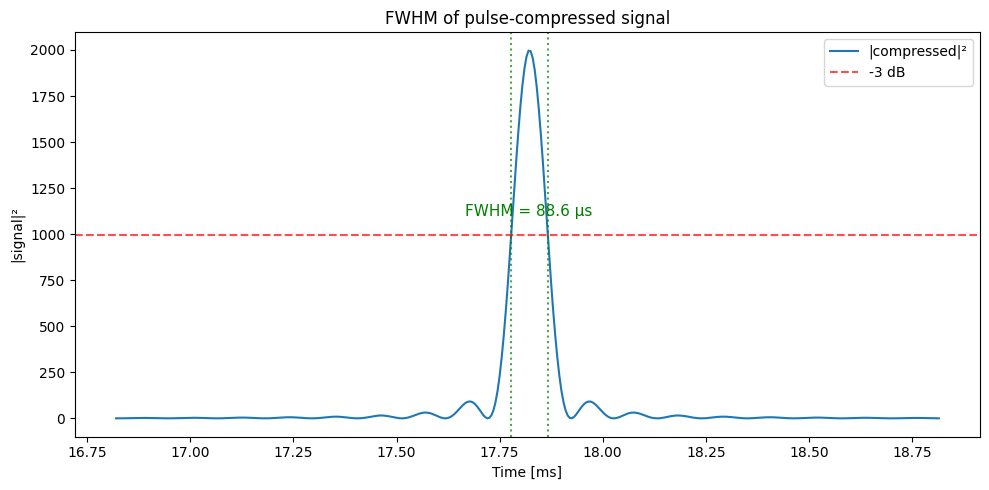

In [68]:
rx_ch = 0
tx_ch = 0
sig_power = np.abs(tdma_compressed[:, rx_ch, tx_ch]) ** 2
t_comp = np.arange(len(sig_power)) / fs

peak_idx = np.argmax(sig_power)
peak_val = sig_power[peak_idx]
half_max = peak_val / 2

left = peak_idx
while left > 0 and sig_power[left] >= half_max:
    left -= 1
t_left = t_comp[left] + (half_max - sig_power[left]) / (sig_power[left + 1] - sig_power[left]) * (t_comp[left + 1] - t_comp[left])

right = peak_idx
while right < len(sig_power) - 1 and sig_power[right] >= half_max:
    right += 1
t_right = t_comp[right - 1] + (half_max - sig_power[right - 1]) / (sig_power[right] - sig_power[right - 1]) * (t_comp[right] - t_comp[right - 1])

fwhm_practical = t_right - t_left
delta_tau_theoretical = 1 / B

print(f"Theoretical: δτ = 1/B = {delta_tau_theoretical*1e6:.2f} µs")
print(f"Measured FWHM: {fwhm_practical*1e6:.2f} µs")
print(f"Ratio: {fwhm_practical / delta_tau_theoretical:.3f}")

window = int(0.001 * fs)
i_start = max(0, peak_idx - window)
i_end = min(len(sig_power), peak_idx + window)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_comp[i_start:i_end] * 1e3, sig_power[i_start:i_end], label="|compressed|²")
ax.axhline(half_max, color="r", linestyle="--", alpha=0.7, label="-3 dB")
ax.axvline(t_left * 1e3, color="g", linestyle=":", alpha=0.7)
ax.axvline(t_right * 1e3, color="g", linestyle=":", alpha=0.7)
ax.text(t_comp[peak_idx] * 1e3, half_max * 1.1, f"FWHM = {fwhm_practical*1e6:.1f} µs",
        ha="center", fontsize=11, color="green")
ax.set_xlabel("Time [ms]")
ax.set_ylabel("|signal|²")
ax.set_title("FWHM of pulse-compressed signal")
ax.legend()
plt.tight_layout()
plt.show()


### Part 2: Virtual Array

1-Tx VA: 32 elements, span = 0.5270 m
2-Tx VA: 64 elements, span = 0.5355 m


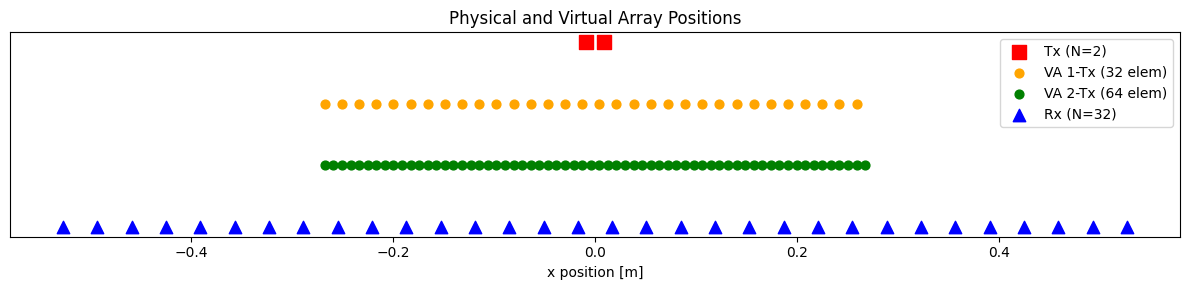


λ = 3.40 cm,  L_va = 0.5355 m
δθ = 0.0635 rad (3.64°)
δx = 25.40 cm  at R=4.0 m
δy = 1.70 cm


In [69]:
# virtual element position: x_va = (x_tx + x_rx) / 2
va_1tx = (tx_pos[0] + rx_pos) / 2

va_2tx = np.array([(tx + rx_pos) / 2 for tx in tx_pos]).flatten()
va_2tx = np.sort(va_2tx)

print(f"1-Tx VA: {len(va_1tx)} elements, span = {va_1tx.ptp():.4f} m")
print(f"2-Tx VA: {len(va_2tx)} elements, span = {va_2tx.ptp():.4f} m")

fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(tx_pos, np.ones(len(tx_pos)) * 0.6, marker="s", s=100, color="red", label=f"Tx (N={Ntx})", zorder=3)
ax.scatter(va_1tx, np.ones(len(va_1tx)) * 0.3, marker="o", s=40, color="orange", label=f"VA 1-Tx ({len(va_1tx)} elem)", zorder=3)
ax.scatter(va_2tx, np.zeros(len(va_2tx)), marker="o", s=40, color="green", label=f"VA 2-Tx ({len(va_2tx)} elem)", zorder=3)
ax.scatter(rx_pos, -np.ones_like(rx_pos) * 0.3, marker="^", s=80, color="blue", label=f"Rx (N={Nrx})", zorder=3)
ax.set_xlabel("x position [m]")
ax.set_yticks([])
ax.set_title("Physical and Virtual Array Positions")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

lam = c / fc
L_va = va_2tx.ptp()
delta_theta = lam / L_va
R = 4.0
delta_x = R * delta_theta
delta_y = c / (2 * B)

print(f"\nλ = {lam*100:.2f} cm,  L_va = {L_va:.4f} m")
print(f"δθ = {delta_theta:.4f} rad ({np.degrees(delta_theta):.2f}°)")
print(f"δx = {delta_x*100:.2f} cm  at R={R} m")
print(f"δy = {delta_y*100:.2f} cm")


### Part 3: Delay-And-Sum

In [70]:
dx = 0.01
dy = 0.01
grid_x = np.arange(-4, 4 + dx, dx)
grid_y = np.arange(0, 4 + dy, dy)

print(f"Grid: {len(grid_x)} x {len(grid_y)} = {len(grid_x)*len(grid_y)} pixels")
print(f"X range: {grid_x[0]:.1f} to {grid_x[-1]:.1f} m, Y range: {grid_y[0]:.1f} to {grid_y[-1]:.1f} m")


def vectorized_das(data, grid_x, grid_y, tx_positions, rx_positions, fs, c):
    if data.ndim == 2:
        data = data[:, :, np.newaxis]

    Nt_data, n_rx, n_tx = data.shape
    GX, GY = np.meshgrid(grid_x, grid_y)
    image = np.zeros((len(grid_y), len(grid_x)), dtype=complex)

    for itx in range(n_tx):
        R_tx = np.sqrt((tx_positions[itx] - GX)**2 + GY**2)
        for irx in range(n_rx):
            R_rx = np.sqrt((rx_positions[irx] - GX)**2 + GY**2)
            R_total = R_tx + R_rx
            idx_map = np.round(R_total / c * fs).astype(int)
            valid = (idx_map >= 0) & (idx_map < Nt_data)
            idx_safe = np.clip(idx_map, 0, Nt_data - 1)
            pixel_values = data[idx_safe, irx, itx]
            pixel_values[~valid] = 0.0
            image += pixel_values

    return image


def plot_das_image(image, grid_x, grid_y, title="DAS Image", dynamic_range=40):
    mag = np.abs(image)
    mag[mag == 0] = np.finfo(float).eps
    img_db = 20 * np.log10(mag / mag.max())

    x_span = float(grid_x[-1] - grid_x[0])
    y_span = float(grid_y[-1] - grid_y[0])
    fig_width = 9
    fig_height = max(4.5, fig_width * (y_span / x_span) + 1.0)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    im = ax.pcolormesh(grid_x, grid_y, img_db, shading="auto",
                       cmap="inferno", vmin=-dynamic_range, vmax=0)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")

    fig.colorbar(im, ax=ax, label="dB", fraction=0.046, pad=0.03)

    plt.tight_layout()
    plt.show()


Grid: 801 x 401 = 321201 pixels
X range: -4.0 to 4.0 m, Y range: 0.0 to 4.0 m


TDMA 2 Tx...
  Done in 0.8 s


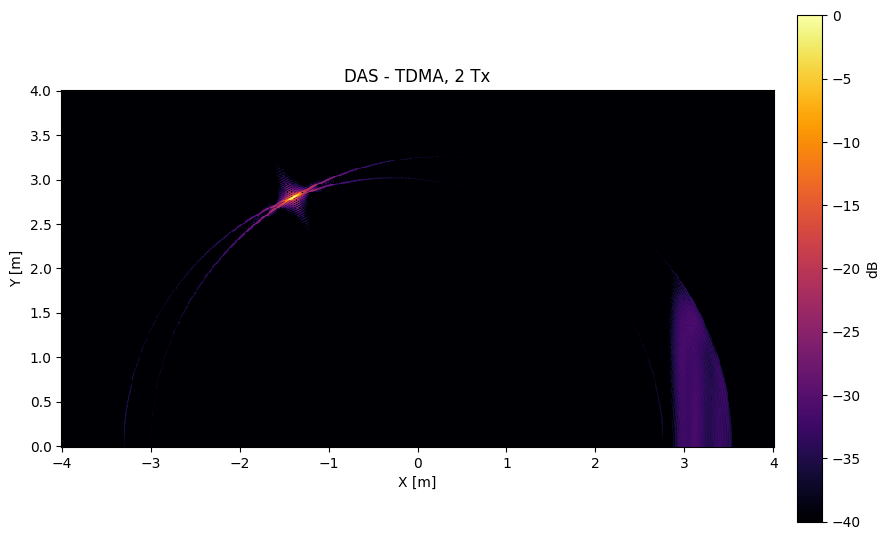

TDMA 1 Tx...
  Done in 0.4 s


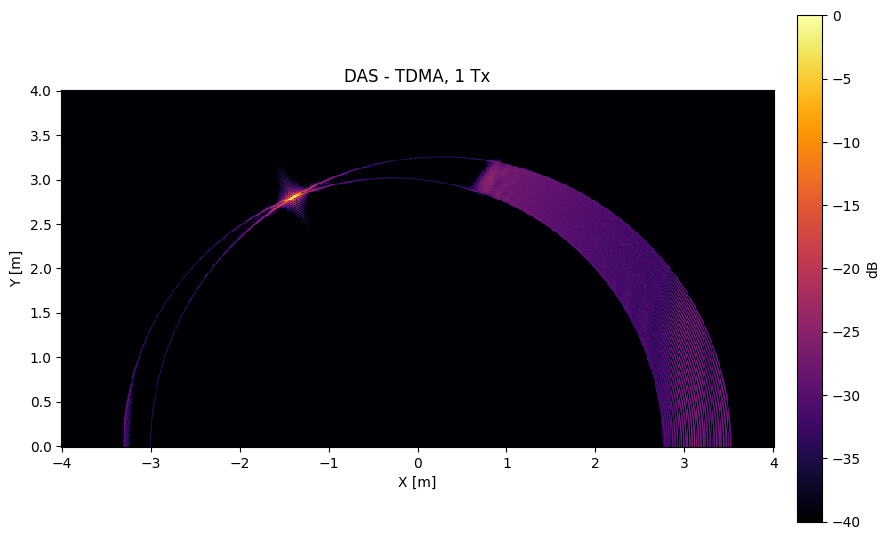

CDMA...
  Done in 0.8 s


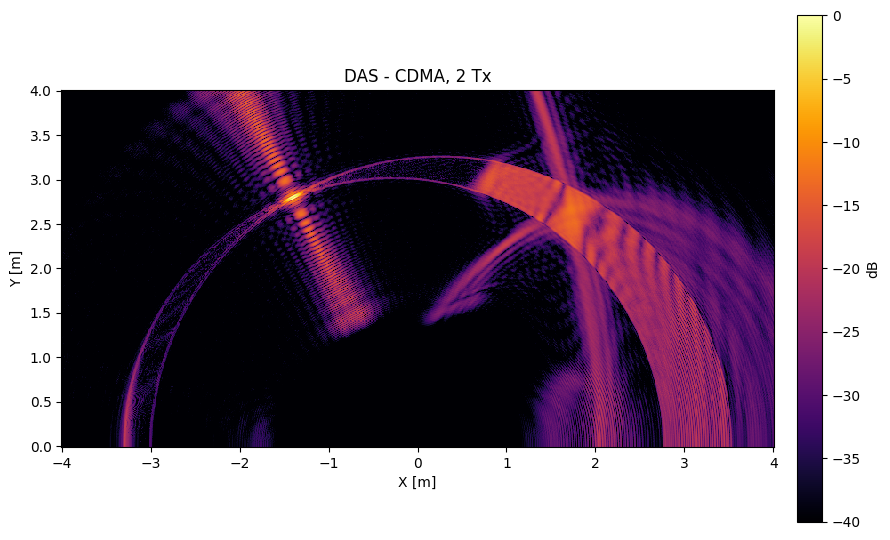

In [71]:
import time

print("TDMA 2 Tx...")
t0 = time.time()
image_tdma_2tx = vectorized_das(tdma_compressed, grid_x, grid_y, tx_pos, rx_pos, fs, c)
print(f"  Done in {time.time() - t0:.1f} s")
plot_das_image(image_tdma_2tx, grid_x, grid_y, title="DAS - TDMA, 2 Tx")

print("TDMA 1 Tx...")
t0 = time.time()
image_tdma_1tx = vectorized_das(tdma_compressed[:, :, 0:1], grid_x, grid_y,
                                 tx_pos[0:1], rx_pos, fs, c)
print(f"  Done in {time.time() - t0:.1f} s")
plot_das_image(image_tdma_1tx, grid_x, grid_y, title="DAS - TDMA, 1 Tx")

# For CDMA, pulse-compress with each replica separately then sum
print("CDMA...")
cdma_compressed_up = np.stack(
    [pulse_compression(cdma_data[:, rx], s_tx_up) for rx in range(Nrx)], axis=1
)
cdma_compressed_down = np.stack(
    [pulse_compression(cdma_data[:, rx], s_tx_down) for rx in range(Nrx)], axis=1
)

t0 = time.time()
image_cdma_up = vectorized_das(cdma_compressed_up, grid_x, grid_y,
                                tx_pos[0:1], rx_pos, fs, c)
image_cdma_down = vectorized_das(cdma_compressed_down, grid_x, grid_y,
                                  tx_pos[1:2], rx_pos, fs, c)
image_cdma = image_cdma_up + image_cdma_down
print(f"  Done in {time.time() - t0:.1f} s")
plot_das_image(image_cdma, grid_x, grid_y, title="DAS - CDMA, 2 Tx")


Reflector at: X = -1.400 m, Y = 2.800 m
Axial FWHM:   2.00 cm  (theory: 1.70 cm)
Lateral FWHM: 4.00 cm  (theory: 25.40 cm)


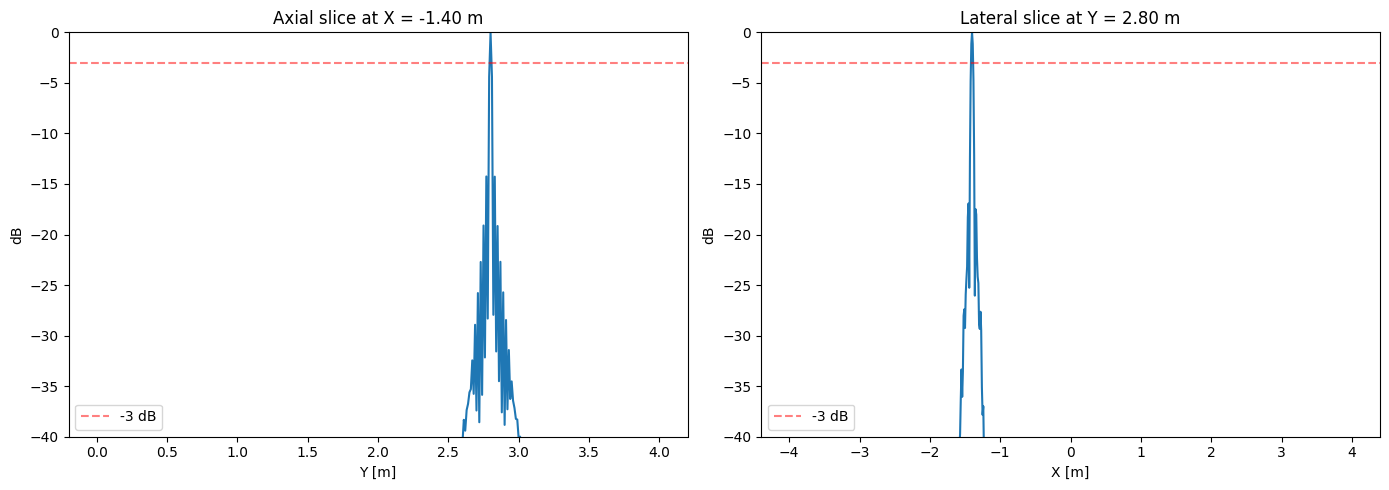

In [72]:
mag = np.abs(image_tdma_2tx)

peak_iy, peak_ix = np.unravel_index(np.argmax(mag), mag.shape)
x_peak = grid_x[peak_ix]
y_peak = grid_y[peak_iy]
print(f"Reflector at: X = {x_peak:.3f} m, Y = {y_peak:.3f} m")

axial_slice = mag[:, peak_ix] ** 2
half_ax = axial_slice[peak_iy] / 2

left_a = peak_iy
while left_a > 0 and axial_slice[left_a] >= half_ax:
    left_a -= 1
right_a = peak_iy
while right_a < len(axial_slice) - 1 and axial_slice[right_a] >= half_ax:
    right_a += 1
fwhm_axial = (right_a - left_a) * dy

lateral_slice = mag[peak_iy, :] ** 2
half_lat = lateral_slice[peak_ix] / 2

left_l = peak_ix
while left_l > 0 and lateral_slice[left_l] >= half_lat:
    left_l -= 1
right_l = peak_ix
while right_l < len(lateral_slice) - 1 and lateral_slice[right_l] >= half_lat:
    right_l += 1
fwhm_lateral = (right_l - left_l) * dx

print(f"Axial FWHM:   {fwhm_axial*100:.2f} cm  (theory: {delta_y*100:.2f} cm)")
print(f"Lateral FWHM: {fwhm_lateral*100:.2f} cm  (theory: {delta_x*100:.2f} cm)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(grid_y, 20 * np.log10(mag[:, peak_ix] / mag.max()))
axes[0].set_xlabel("Y [m]")
axes[0].set_ylabel("dB")
axes[0].set_title(f"Axial slice at X = {x_peak:.2f} m")
axes[0].set_ylim([-40, 0])
axes[0].axhline(-3, color="r", linestyle="--", alpha=0.5, label="-3 dB")
axes[0].legend()

axes[1].plot(grid_x, 20 * np.log10(mag[peak_iy, :] / mag.max()))
axes[1].set_xlabel("X [m]")
axes[1].set_ylabel("dB")
axes[1].set_title(f"Lateral slice at Y = {y_peak:.2f} m")
axes[1].set_ylim([-40, 0])
axes[1].axhline(-3, color="r", linestyle="--", alpha=0.5, label="-3 dB")
axes[1].legend()

plt.tight_layout()
plt.show()


### Part 4: Tapering Hamming Apodization

tdma_compressed_tapered shape: (10000, 32, 2)
Running tapered DAS...
  Done in 0.9 s


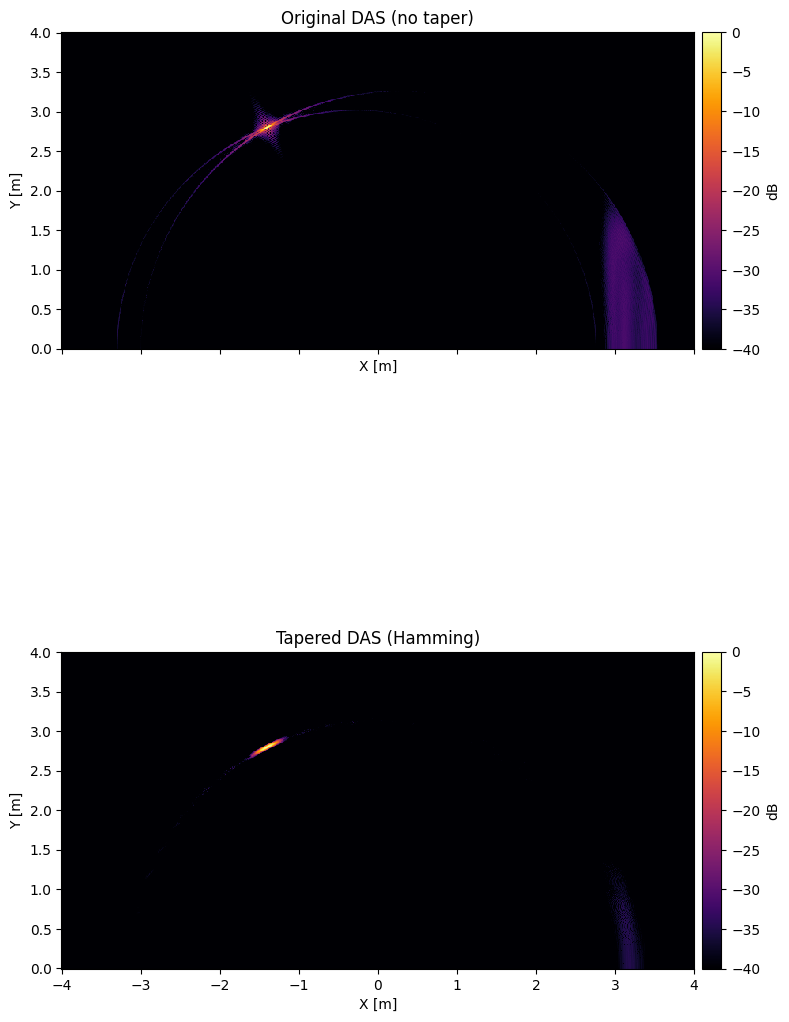

  [No taper]
    Axial FWHM:  2.00 cm
    Lateral FWHM: 4.00 cm
    PSL: -18.0 dB
  [Hamming taper]
    Axial FWHM:  4.00 cm
    Lateral FWHM: 6.00 cm
    PSL: -32.7 dB

Sidelobe reduction: -18.0 → -32.7 dB (14.7 dB improvement)
Mainlobe widening:  axial 2.00 → 4.00 cm, lateral 4.00 → 6.00 cm


In [73]:
w_rx = np.hamming(Nrx)
w_tx = np.hamming(len(s_tx_up))

s_tx_up_tapered = s_tx_up * w_tx

tdma_compressed_tapered = np.stack(
    [
        np.stack(
            [pulse_compression(tdma_data[:, rx, tx], s_tx_up_tapered) for rx in range(Nrx)],
            axis=1,
        )
        for tx in range(Ntx)
    ],
    axis=2,
)
print(f"tdma_compressed_tapered shape: {tdma_compressed_tapered.shape}")


def vectorized_das_weighted(data, grid_x, grid_y, tx_positions, rx_positions, fs, c, rx_weights=None):
    if data.ndim == 2:
        data = data[:, :, np.newaxis]

    Nt_data, n_rx, n_tx = data.shape
    GX, GY = np.meshgrid(grid_x, grid_y)
    image = np.zeros((len(grid_y), len(grid_x)), dtype=complex)

    if rx_weights is None:
        rx_weights = np.ones(n_rx)

    for itx in range(n_tx):
        R_tx = np.sqrt((tx_positions[itx] - GX)**2 + GY**2)
        for irx in range(n_rx):
            R_rx = np.sqrt((rx_positions[irx] - GX)**2 + GY**2)
            idx_map = np.round((R_tx + R_rx) / c * fs).astype(int)
            valid = (idx_map >= 0) & (idx_map < Nt_data)
            idx_safe = np.clip(idx_map, 0, Nt_data - 1)
            pixel_values = data[idx_safe, irx, itx]
            pixel_values[~valid] = 0.0
            image += rx_weights[irx] * pixel_values

    return image


print("Running tapered DAS...")
t0 = time.time()
image_tapered = vectorized_das_weighted(
    tdma_compressed_tapered, grid_x, grid_y, tx_pos, rx_pos, fs, c, rx_weights=w_rx
)
print(f"  Done in {time.time() - t0:.1f} s")

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(2, 1, figsize=(8, 14), sharex=True, sharey=True)

for ax, img, title in zip(axes,
                           [image_tdma_2tx, image_tapered],
                           ["Original DAS (no taper)", "Tapered DAS (Hamming)"]):
    mag = np.abs(img)
    mag[mag == 0] = np.finfo(float).eps
    img_db = 20 * np.log10(mag / mag.max())
    im = ax.pcolormesh(grid_x, grid_y, img_db, shading="auto",
                       cmap="inferno", vmin=-40, vmax=0)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.08)
    fig.colorbar(im, cax=cax, label="dB")

plt.tight_layout()
plt.show()


def measure_fwhm_and_psl(image, grid_x, grid_y, dx, dy, label=""):
    mag = np.abs(image)
    peak_iy, peak_ix = np.unravel_index(np.argmax(mag), mag.shape)

    axial = mag[:, peak_ix] ** 2
    half_a = axial[peak_iy] / 2
    la = peak_iy
    while la > 0 and axial[la] >= half_a:
        la -= 1
    ra = peak_iy
    while ra < len(axial) - 1 and axial[ra] >= half_a:
        ra += 1
    fwhm_ax = (ra - la) * dy

    lateral = mag[peak_iy, :] ** 2
    half_l = lateral[peak_ix] / 2
    ll = peak_ix
    while ll > 0 and lateral[ll] >= half_l:
        ll -= 1
    rl = peak_ix
    while rl < len(lateral) - 1 and lateral[rl] >= half_l:
        rl += 1
    fwhm_lat = (rl - ll) * dx

    lat_db = 20 * np.log10(mag[peak_iy, :] / mag[peak_iy, :].max() + np.finfo(float).eps)
    mainlobe_width = max(rl - ll, 5)
    sidelobe_region = lat_db.copy()
    sl_left = max(0, peak_ix - mainlobe_width)
    sl_right = min(len(lat_db), peak_ix + mainlobe_width + 1)
    sidelobe_region[sl_left:sl_right] = -np.inf
    psl = np.max(sidelobe_region)

    print(f"  [{label}]")
    print(f"    Axial FWHM:  {fwhm_ax*100:.2f} cm")
    print(f"    Lateral FWHM: {fwhm_lat*100:.2f} cm")
    print(f"    PSL: {psl:.1f} dB")
    return fwhm_ax, fwhm_lat, psl


fwhm_ax_orig, fwhm_lat_orig, psl_orig = measure_fwhm_and_psl(
    image_tdma_2tx, grid_x, grid_y, dx, dy, label="No taper")
fwhm_ax_tap, fwhm_lat_tap, psl_tap = measure_fwhm_and_psl(
    image_tapered, grid_x, grid_y, dx, dy, label="Hamming taper")

print(f"\nSidelobe reduction: {psl_orig:.1f} → {psl_tap:.1f} dB ({psl_orig - psl_tap:.1f} dB improvement)")
print(f"Mainlobe widening:  axial {fwhm_ax_orig*100:.2f} → {fwhm_ax_tap*100:.2f} cm, "
      f"lateral {fwhm_lat_orig*100:.2f} → {fwhm_lat_tap*100:.2f} cm")


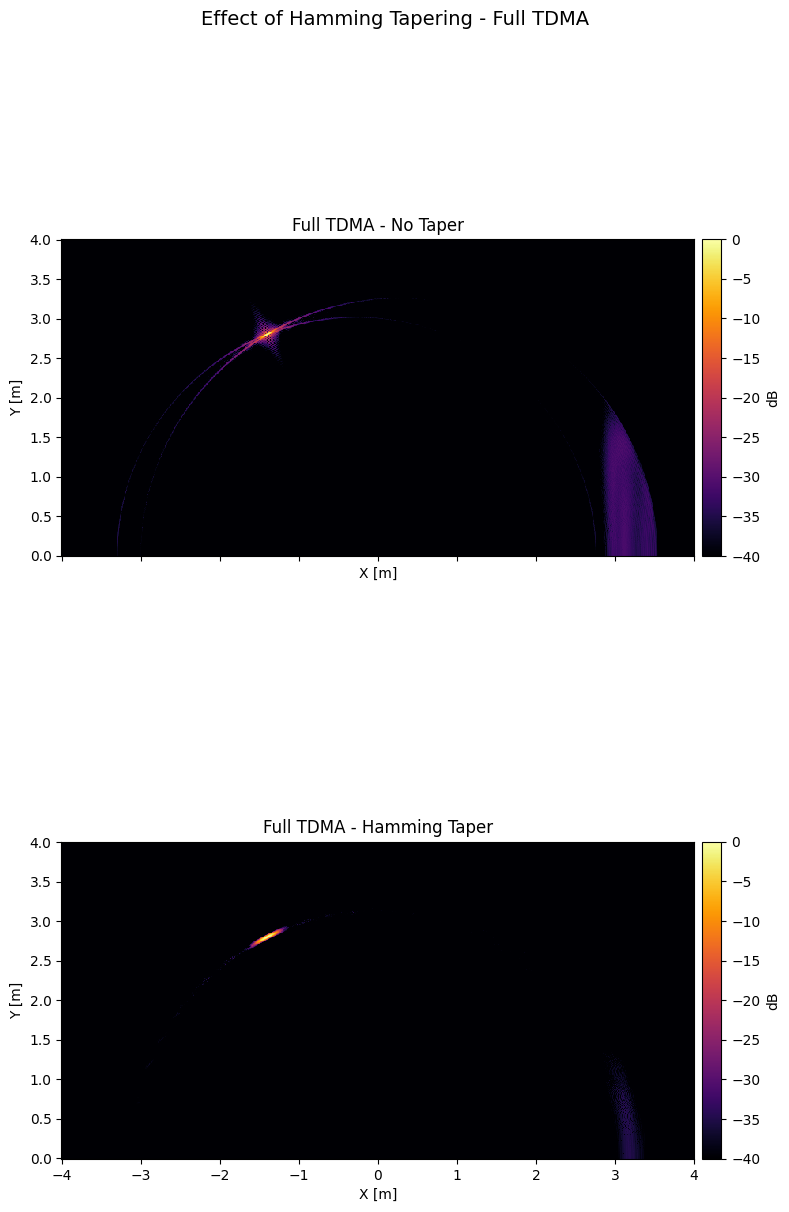

In [74]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(2, 1, figsize=(8, 14), sharex=True, sharey=True)
for ax, img, title in zip(axes,
                           [image_tdma_2tx, image_tapered],
                           ["Full TDMA - No Taper", "Full TDMA - Hamming Taper"]):
    m = np.abs(img)
    m[m == 0] = np.finfo(float).eps
    db = 20 * np.log10(m / m.max())
    im = ax.pcolormesh(grid_x, grid_y, db, shading="auto", cmap="inferno", vmin=-40, vmax=0)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.08)
    fig.colorbar(im, cax=cax, label="dB")
plt.suptitle("Effect of Hamming Tapering - Full TDMA", fontsize=14)
plt.tight_layout()
plt.show()


Hamming tapering suppresses sidelobes around the reflectors, making the image cleaner. However, the mainlobe widens in both axial and lateral directions, meaning we trade resolution for lower sidelobe artifacts. The reflector peaks are more distinct from the background.

Running tapered DAS (1 Tx)...
  Done in 0.4 s


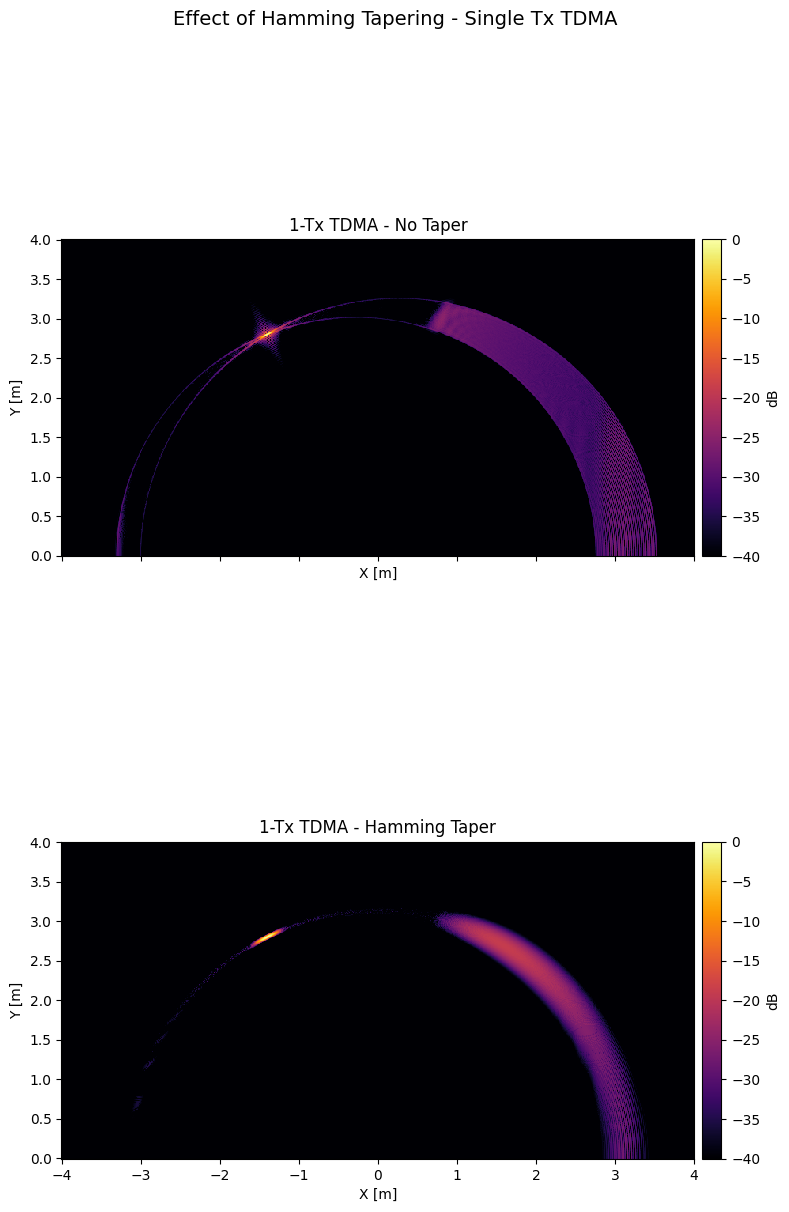

In [75]:
print("Running tapered DAS (1 Tx)...")
t0 = time.time()
image_1tx_tapered = vectorized_das_weighted(
    tdma_compressed_tapered[:, :, 0:1], grid_x, grid_y,
    tx_pos[0:1], rx_pos, fs, c, rx_weights=w_rx
)
print(f"  Done in {time.time() - t0:.1f} s")

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(2, 1, figsize=(8, 14), sharex=True, sharey=True)
for ax, img, title in zip(axes,
                           [image_tdma_1tx, image_1tx_tapered],
                           ["1-Tx TDMA - No Taper", "1-Tx TDMA - Hamming Taper"]):
    m = np.abs(img)
    m[m == 0] = np.finfo(float).eps
    db = 20 * np.log10(m / m.max())
    im = ax.pcolormesh(grid_x, grid_y, db, shading="auto", cmap="inferno", vmin=-40, vmax=0)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.08)
    fig.colorbar(im, cax=cax, label="dB")
plt.suptitle("Effect of Hamming Tapering - Single Tx TDMA", fontsize=14)
plt.tight_layout()
plt.show()


With only 1 Tx, the virtual array is half the density, so the lateral resolution is fundamentally degraded (wider mainlobe). Tapering reduces sidelobes somewhat, but it does **not** solve the underlying problem: the aperture is simply too small. The poor lateral resolution is a consequence of the reduced virtual aperture, not of sidelobes. Tapering only helps with sidelobe suppression, not aperture size.